<ipython-input-1-81081d42dde2>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(sort_names))


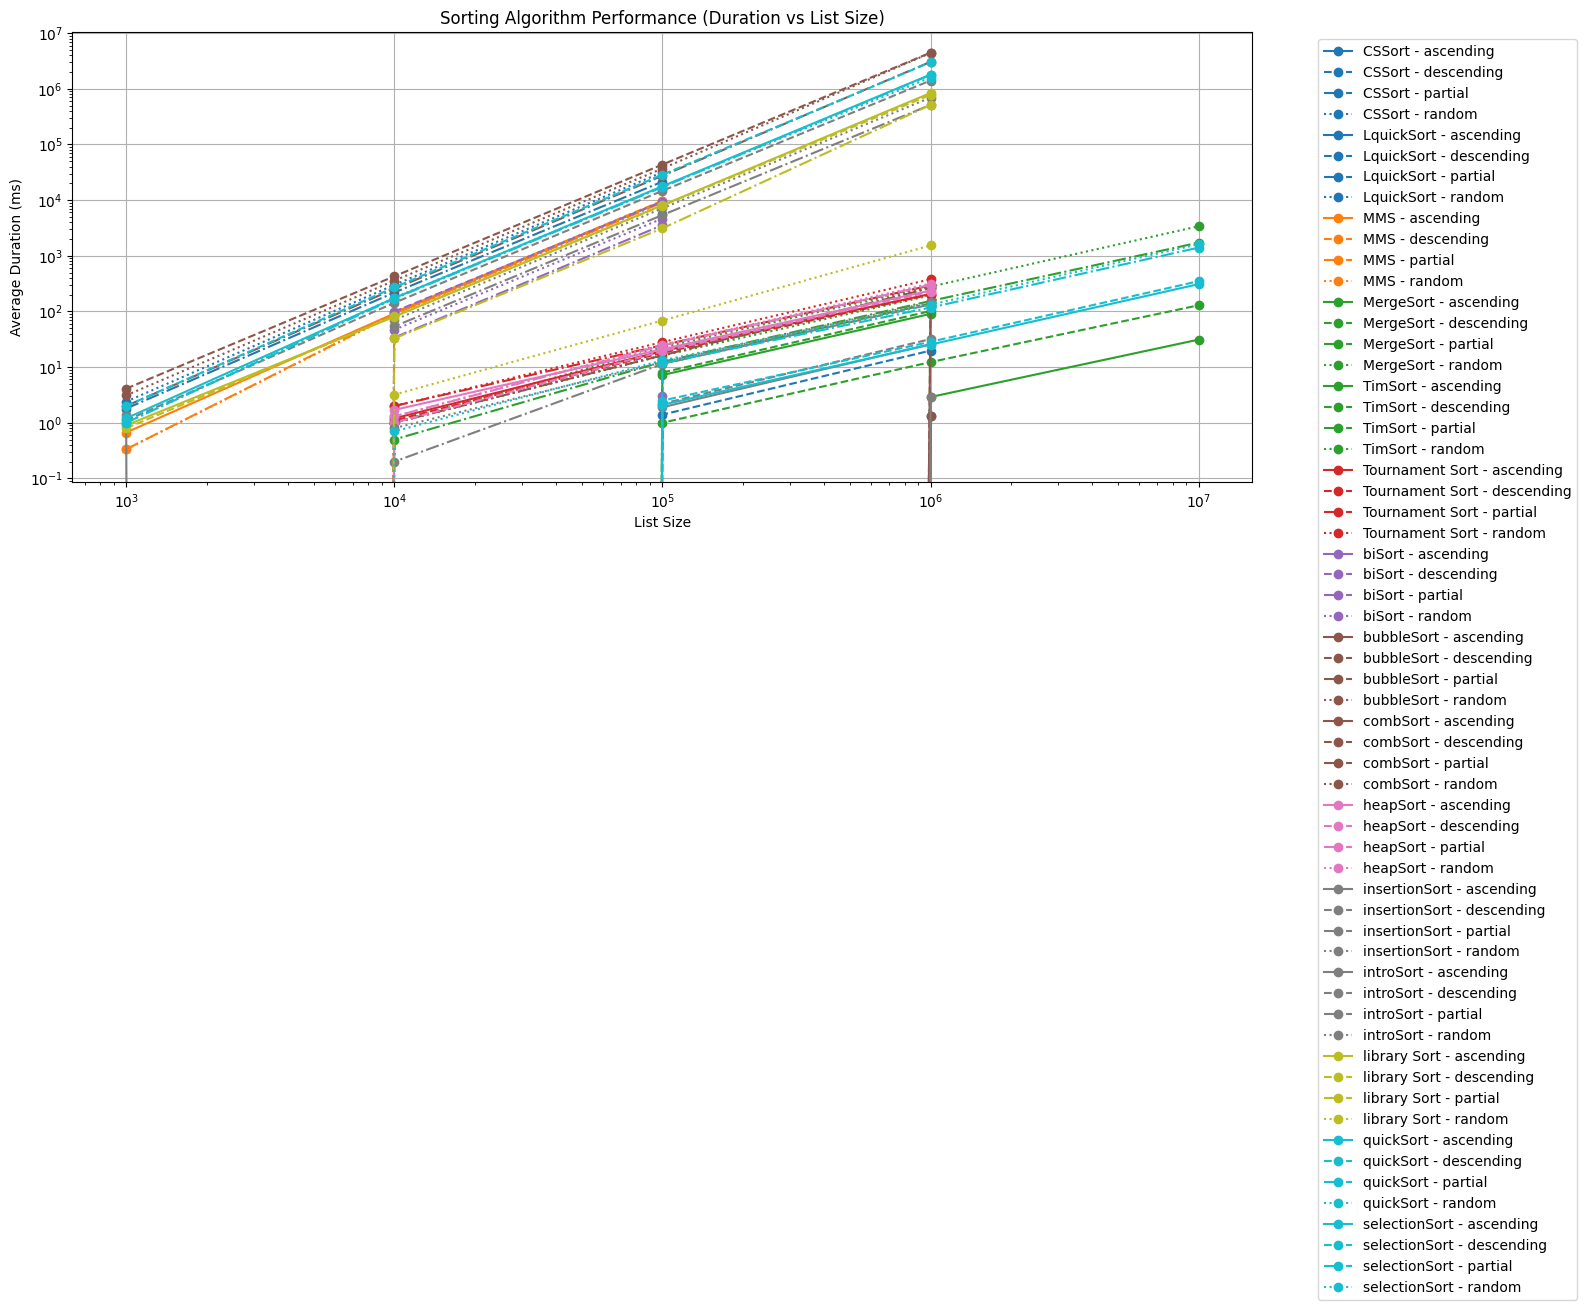

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.cm as cm
import numpy as np

# 📁 경로 설정
folder_path = "/content/result"

# 📊 데이터 저장 구조
data = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# 📁 CSV 파일 파싱
for filename in os.listdir(folder_path):
    if not filename.endswith(".csv"):
        continue

    parts = filename.split("_")
    if len(parts) < 3:
        continue

    sort_name = parts[1]
    try:
        list_size = int(parts[2].replace(".csv", "").replace(".CSV", ""))
    except ValueError:
        continue

    df = pd.read_csv(os.path.join(folder_path, filename))

    for _, row in df.iterrows():
        list_type = row["ListType"]
        duration = row["Duration(ms)"]
        data[sort_name][list_type][list_size].append(duration)

# 🎨 라인 스타일: 리스트 타입
line_styles = {
    "ascending": "solid",
    "descending": "dashed",
    "partial": "dashdot",
    "random": "dotted"
}

# 🎨 정렬 알고리즘 이름 → 색상 자동 매핑
sort_names = sorted(data.keys())
colors = cm.get_cmap("tab10", len(sort_names))
sort_color_map = {name: colors(i) for i, name in enumerate(sort_names)}

# 📊 시각화 (하나의 그래프에 모든 정렬 종류 포함)
plt.figure(figsize=(16, 10))
plt.title("Sorting Algorithm Performance (Duration vs List Size)")
plt.xlabel("List Size")
plt.ylabel("Average Duration (ms)")
plt.xscale("log")
plt.yscale("log")

for sort_name in sort_names:
    color = sort_color_map[sort_name]
    for list_type in data[sort_name]:
        x = []
        y = []
        for size in sorted(data[sort_name][list_type]):
            durations = data[sort_name][list_type][size]
            avg_duration = sum(durations) / len(durations)
            x.append(size)
            y.append(avg_duration)

        label = f"{sort_name} - {list_type}"
        plt.plot(x, y,
                 label=label,
                 color=color,
                 linestyle=line_styles.get(list_type, "solid"),
                 marker='o',
                 markersize=6)

plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


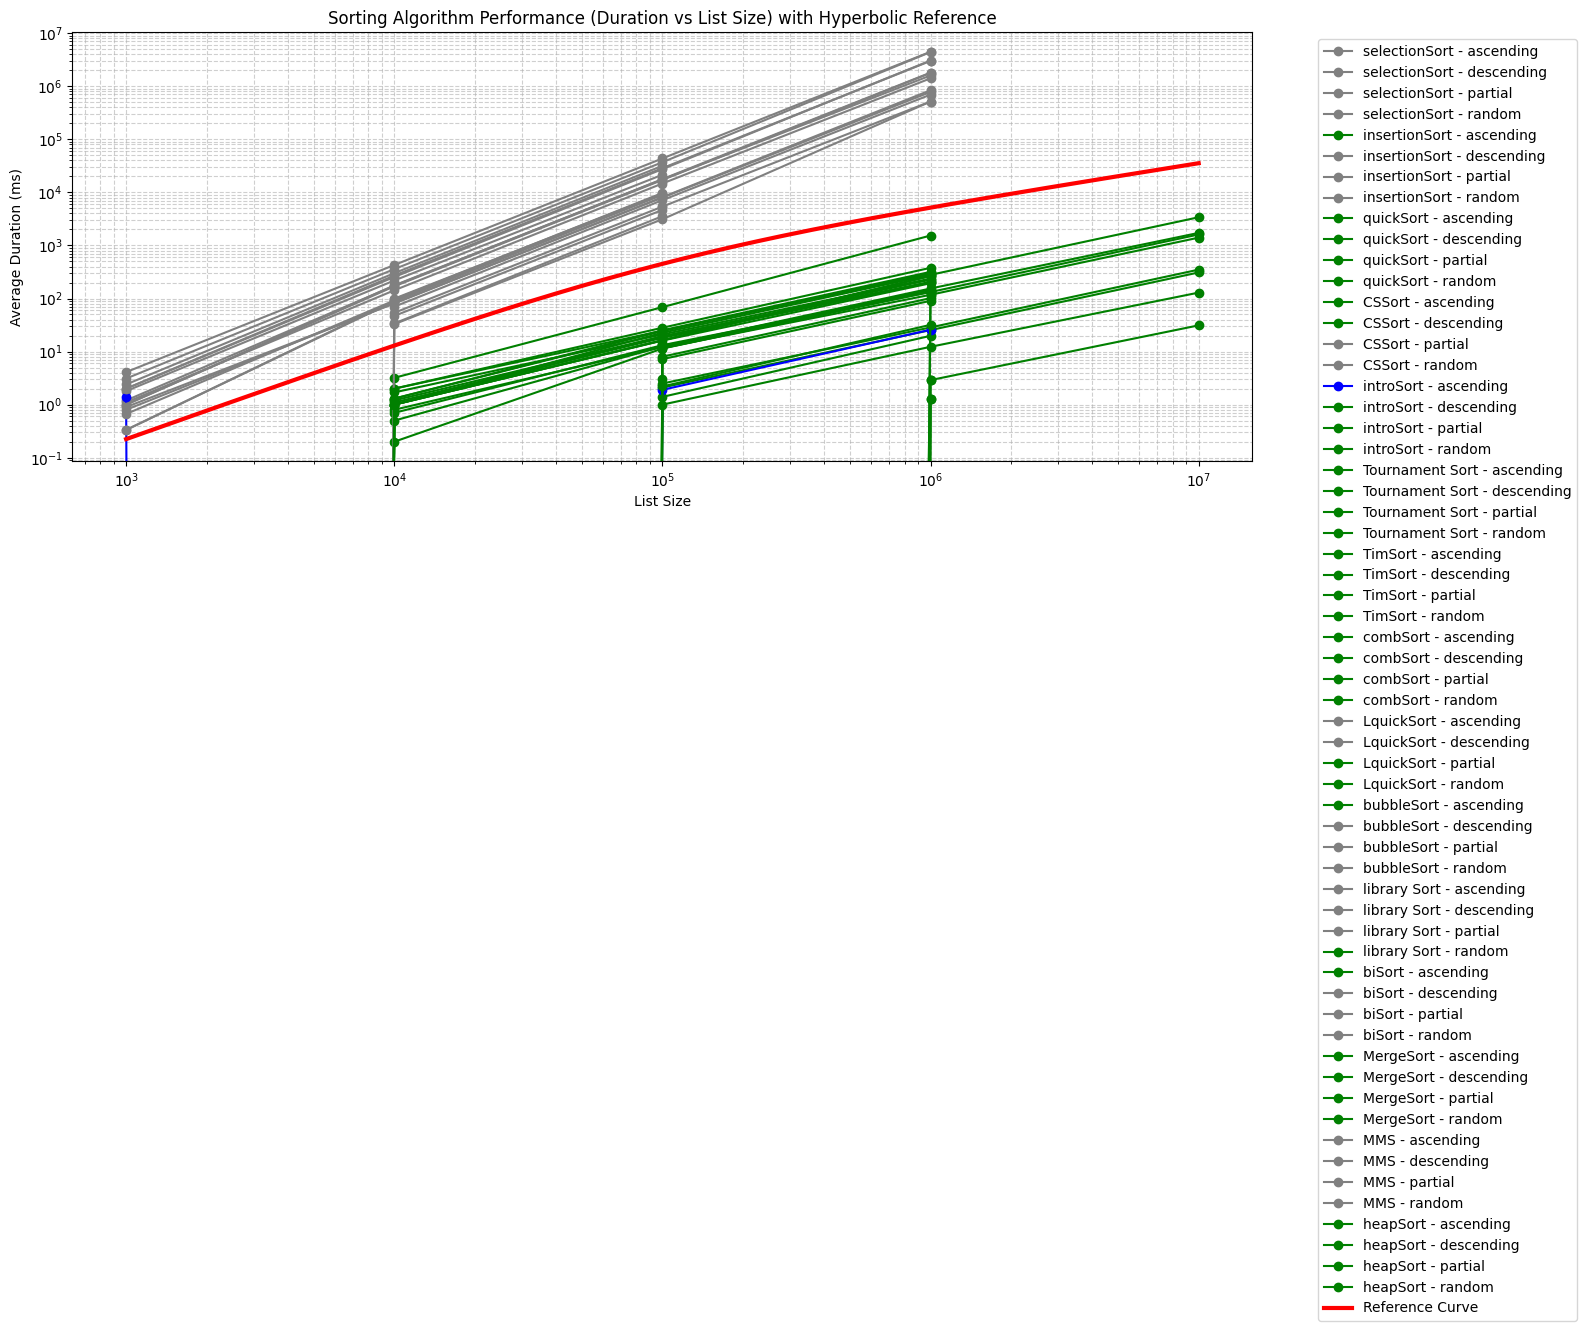

🔺 기준선 위 정렬 알고리즘 (느림):
 - CSSort - partial
 - CSSort - random
 - LquickSort - ascending
 - LquickSort - descending
 - MMS - ascending
 - MMS - descending
 - MMS - partial
 - MMS - random
 - biSort - descending
 - biSort - partial
 - biSort - random
 - bubbleSort - descending
 - bubbleSort - partial
 - bubbleSort - random
 - insertionSort - descending
 - insertionSort - partial
 - insertionSort - random
 - library Sort - ascending
 - library Sort - descending
 - library Sort - partial
 - selectionSort - ascending
 - selectionSort - descending
 - selectionSort - partial
 - selectionSort - random

🟢 기준선 아래 정렬 알고리즘 (빠름):
 - CSSort - ascending
 - CSSort - descending
 - LquickSort - partial
 - LquickSort - random
 - MergeSort - ascending
 - MergeSort - descending
 - MergeSort - partial
 - MergeSort - random
 - TimSort - ascending
 - TimSort - descending
 - TimSort - partial
 - TimSort - random
 - Tournament Sort - ascending
 - Tournament Sort - descending
 - Tournament Sort - partial
 - Tourn

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.cm as cm
import numpy as np

# 📁 경로 설정
folder_path = "/content/result"

# 📊 데이터 저장 구조
data = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# 📁 CSV 파싱
if os.path.exists(folder_path):
    for filename in os.listdir(folder_path):
        if not filename.endswith(".csv"):
            continue
        parts = filename.split("_")
        if len(parts) < 3:
            continue
        sort_name = parts[1]
        try:
            list_size = int(parts[2].replace(".csv", "").replace(".CSV", ""))
        except ValueError:
            continue

        df = pd.read_csv(os.path.join(folder_path, filename))
        for _, row in df.iterrows():
            list_type = row["ListType"]
            duration = row["Duration(ms)"]
            data[sort_name][list_type][list_size].append(duration)

# ✅ 기준 곡선 (쌍곡선 느낌)
def reference_curve(x):
    return 0.9e-6 * np.power(x, 1.8) / (1 + 1e-5 * x)  # 조절 가능

# ✅ 그룹 분류
group_above = []
group_below = []
group_mixed = []

# ✅ 시각화 시작
plt.figure(figsize=(16, 10))
plt.title("Sorting Algorithm Performance (Duration vs List Size) with Hyperbolic Reference")
plt.xlabel("List Size")
plt.ylabel("Average Duration (ms)")
plt.xscale("log")
plt.yscale("log")

for sort_name in data:
    for list_type in data[sort_name]:
        x_vals = sorted(data[sort_name][list_type].keys())
        y_vals = [np.mean(data[sort_name][list_type][x]) for x in x_vals]

        # 유효한 (y > 0) 구간만 비교
        comparisons = [(x, y) for x, y in zip(x_vals, y_vals) if y > 0]
        if not comparisons:
            continue  # y 값이 모두 0 이하인 경우는 생략

        # 기준선 비교
        above = all(y > reference_curve(x) for x, y in comparisons)
        below = all(y < reference_curve(x) for x, y in comparisons)

        label = f"{sort_name} - {list_type}"
        color = 'gray' if above else ('green' if below else 'blue')
        plt.plot(x_vals, y_vals, label=label, color=color, linestyle='-', marker='o')

        if above:
            group_above.append(label)
        elif below:
            group_below.append(label)
        else:
            group_mixed.append(label)

# 기준 곡선 그리기
x_curve = np.logspace(3, 7, 300)
y_curve = reference_curve(x_curve)
plt.plot(x_curve, y_curve, color='red', linewidth=3, label='Reference Curve')

plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ✅ 결과 출력
print("🔺 기준선 위 정렬 알고리즘 (느림):")
for name in sorted(group_above):
    print(" -", name)

print("\n🟢 기준선 아래 정렬 알고리즘 (빠름):")
for name in sorted(group_below):
    print(" -", name)

print("\n⚪ 기준선을 넘나드는 정렬 알고리즘 (혼합):")
for name in sorted(group_mixed):
    print(" -", name)


#4.1 Selection Sort Optimization

,ListType,Selection Avg Time (ms),MMS Avg Time (ms),Improvement (%)
0,ascending,17744.6,9486.67,46.54
1,descending,28613.6,9736.33,65.97
2,partial,17157.0,9035.67,47.34
3,random,17514.2,9063.33,48.25


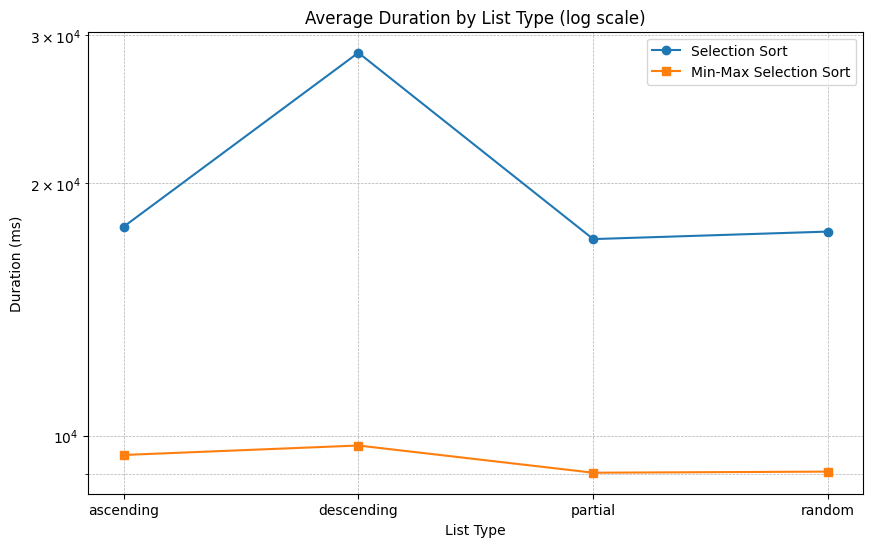

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# 1. 파일 로드
selection_file = glob.glob('result/*selectionSort_100000*.csv')[0]
mms_file = glob.glob('result/*MMS_100000*.csv')[0]

selection_df = pd.read_csv(selection_file)
mms_df = pd.read_csv(mms_file)

# 2. 평균 시간 계산
selection_avg = selection_df.groupby('ListType')['Duration(ms)'].mean()
mms_avg = mms_df.groupby('ListType')['Duration(ms)'].mean()

# 3. 성능 향상 비율 계산
improvement = (1 - mms_avg / selection_avg) * 100
summary_df = pd.DataFrame({
    'Selection Avg Time (ms)': selection_avg,
    'MMS Avg Time (ms)': mms_avg,
    'Improvement (%)': improvement
}).reset_index()

# 4. 표 출력
from IPython.display import display
display(summary_df.round(2))

# 5. 그래프 그리기 (log-log scale)
plt.figure(figsize=(10, 6))
plt.plot(summary_df['ListType'], selection_avg, marker='o', label='Selection Sort')
plt.plot(summary_df['ListType'], mms_avg, marker='s', label='Min-Max Selection Sort')
plt.yscale('log')
plt.title('Average Duration by List Type (log scale)')
plt.xlabel('List Type')
plt.ylabel('Duration (ms)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()


#4.2 Binary Search-Based Insertion Sort Optimization

,ListType,Insertion Avg Time (ms),Binary Insertion Avg Time (ms),Improvement (%)
0,ascending,0.0,3.0,-inf
1,descending,14698.5,9409.0,35.99
2,partial,5392.0,3556.4,34.04
3,random,7133.8,4671.2,34.52


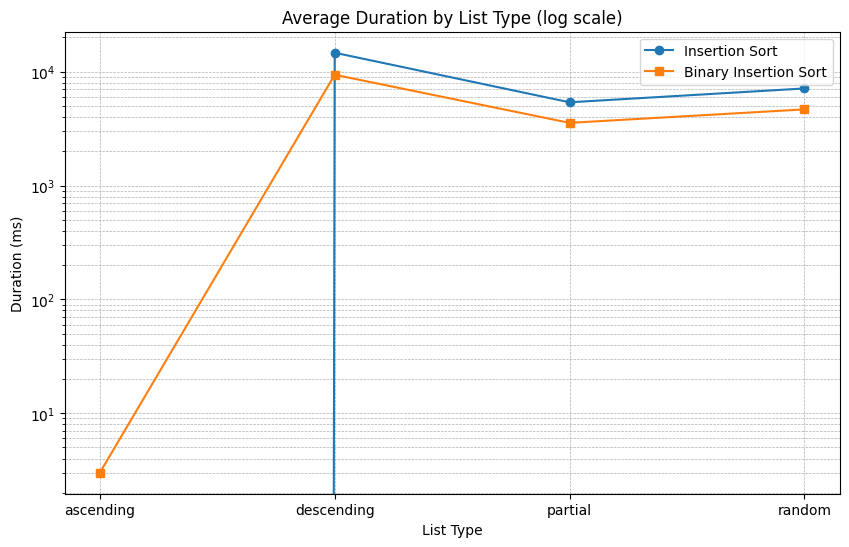

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# 1. 파일 경로 찾기
import os

def find_exact_file(pattern_keyword):
    files = os.listdir('result')
    return next(f'result/{f}' for f in files if pattern_keyword in f and '_100000.' in f)

# 정확한 파일명만 선택
insertion_file = find_exact_file('insertionSort')
bisort_file = find_exact_file('biSort')


# 2. 데이터 읽기
insertion_df = pd.read_csv(insertion_file)
bisort_df = pd.read_csv(bisort_file)

# 3. 평균 실행 시간 계산
insertion_avg = insertion_df.groupby('ListType')['Duration(ms)'].mean()
bisort_avg = bisort_df.groupby('ListType')['Duration(ms)'].mean()

# 4. 성능 향상률 계산
improvement = (1 - bisort_avg / insertion_avg) * 100
summary_df = pd.DataFrame({
    'Insertion Avg Time (ms)': insertion_avg,
    'Binary Insertion Avg Time (ms)': bisort_avg,
    'Improvement (%)': improvement
}).reset_index()

# 5. 표 출력
from IPython.display import display
display(summary_df.round(2))

# 6. 그래프 (log-log scale)
plt.figure(figsize=(10, 6))
plt.plot(summary_df['ListType'], insertion_avg, marker='o', label='Insertion Sort')
plt.plot(summary_df['ListType'], bisort_avg, marker='s', label='Binary Insertion Sort')
plt.yscale('log')
plt.title('Average Duration by List Type (log scale)')
plt.xlabel('List Type')
plt.ylabel('Duration (ms)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()


#4.4 Optimizing Quick Sort with Median-of-Three Pivot Selection

,ListType,LquickSort Avg Time (ms),quickSort Avg Time (ms),Improvement (%)
0,ascending,5609.4,2.1,99.96
1,descending,15960.8,2.5,99.98
2,partial,13.4,11.7,12.69
3,random,14.0,13.2,5.71


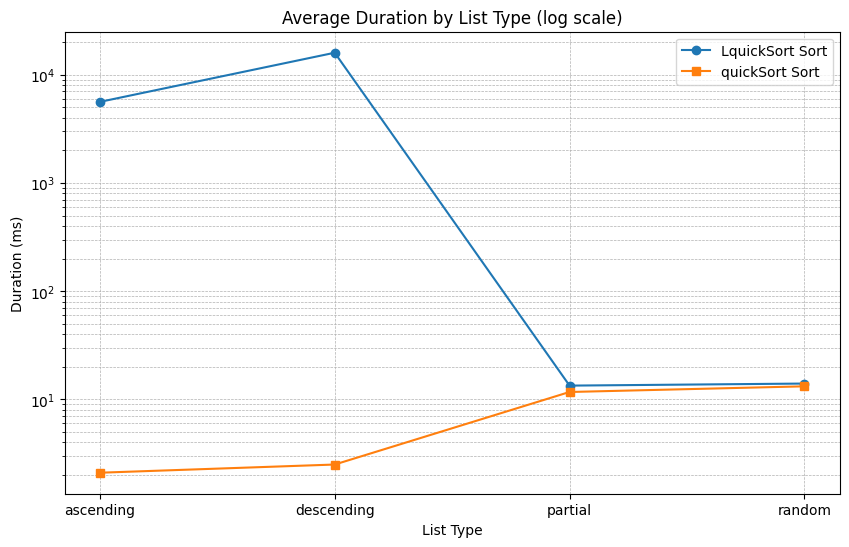

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# 정확하게 파일을 구분 (LquickSort만 포함되게, quickSort는 LquickSort를 제외하게)
LquickSort_file = glob.glob('result/*LquickSort_100000*.csv')[0]
quickSort_file = [f for f in glob.glob('result/*quickSort_100000*.csv') if 'LquickSort' not in f][0]


# 2. 데이터 읽기
LquickSort_df = pd.read_csv(LquickSort_file)
quickSort_df = pd.read_csv(quickSort_file)

# 3. 평균 실행 시간 계산
LquickSort_avg = LquickSort_df.groupby('ListType')['Duration(ms)'].mean()
quickSort_avg = quickSort_df.groupby('ListType')['Duration(ms)'].mean()

# 4. 성능 향상률 계산
improvement = (1 - quickSort_avg / LquickSort_avg) * 100
summary_df = pd.DataFrame({
    'LquickSort Avg Time (ms)': LquickSort_avg,
    'quickSort Avg Time (ms)': quickSort_avg,
    'Improvement (%)': improvement
}).reset_index()

# 5. 표 출력
from IPython.display import display
display(summary_df.round(2))

# 6. 그래프 (log-log scale)
plt.figure(figsize=(10, 6))
plt.plot(summary_df['ListType'], LquickSort_avg, marker='o', label='LquickSort Sort')
plt.plot(summary_df['ListType'], quickSort_avg, marker='s', label='quickSort Sort')
plt.yscale('log')
plt.title('Average Duration by List Type (log scale)')
plt.xlabel('List Type')
plt.ylabel('Duration (ms)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()
